In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/student1.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72.0,72.0,74.0
1,female,group C,some college,standard,completed,69.0,90.0,88.0
2,female,group B,master's degree,standard,none,90.0,95.0,93.0
3,male,group A,associate's degree,free/reduced,none,47.0,57.0,44.0
4,male,group C,some college,standard,none,76.0,78.0,75.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1000 non-null   object 
 1   race/ethnicity               1000 non-null   object 
 2   parental level of education  993 non-null    object 
 3   lunch                        1000 non-null   object 
 4   test preparation course      1000 non-null   object 
 5   math score                   995 non-null    float64
 6   reading score                996 non-null    float64
 7   writing score                997 non-null    float64
dtypes: float64(3), object(5)
memory usage: 62.6+ KB


In [ ]:
#Type error or numeric

df['math score']=pd.to_numeric(df['math score'])

In [ ]:
print(df['math score'].dtype)

float64


In [ ]:
# prompt: how to convert the data to numeric

# Convert 'reading score' and 'writing score' columns to numeric, coercing errors to NaN
df['reading score'] = pd.to_numeric(df['reading score'], errors='coerce')
df['writing score'] = pd.to_numeric(df['writing score'], errors='coerce')

# Print data types to verify the conversion
print(df['reading score'].dtype)
print(df['writing score'].dtype)

# Handle NaN values (optional) - you might want to replace NaN with the mean/median or drop the rows
# Example: Fill NaN values with the mean
"""df['reading score'].fillna(df['reading score'].mean(), inplace=True)
df['writing score'].fillna(df['writing score'].mean(), inplace=True)"""


float64
float64


"df['reading score'].fillna(df['reading score'].mean(), inplace=True)\ndf['writing score'].fillna(df['writing score'].mean(), inplace=True)"

In [ ]:
# prompt: how if i want to change it to integer

# Check for non-numeric values in 'math score' column
non_numeric_math = df[~df['math score'].astype(str).str.isdigit()]
print("Non-numeric values in 'math score':\n", non_numeric_math)



# If you find non-numeric values, you might need to handle them before converting to numeric.
# For example:
# 1. Replace non-numeric values with NaN:
df['math score'] = pd.to_numeric(df['math score'], errors='coerce')

# 2. Remove rows with non-numeric values:
# df = df[pd.to_numeric(df['math score'], errors='coerce').notnull()]
# ... similar for 'reading score' and 'writing score'

# 3. Replace non-numeric values with a specific value (e.g. the mean):
# df['math score'] = pd.to_numeric(df['math score'], errors='coerce').fillna(df['math score'].mean())
# ... similar for 'reading score' and 'writing score'


print(df['math score'].dtype)



Non-numeric values in 'math score':
      gender race/ethnicity parental level of education         lunch  \
0    female        group B           bachelor's degree      standard   
1    female        group C                some college      standard   
2    female        group B             master's degree      standard   
3      male        group A          associate's degree  free/reduced   
4      male        group C                some college      standard   
..      ...            ...                         ...           ...   
995  female        group E             master's degree      standard   
996    male        group C                 high school  free/reduced   
997  female        group C                 high school  free/reduced   
998  female        group D                some college      standard   
999  female        group D                some college  free/reduced   

    test preparation course  math score  reading score  writing score  
0                      non

In [ ]:
df['math score'].dtype

dtype('float64')

In [ ]:
df.shape

(1000, 8)

In [ ]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,7
lunch,0
test preparation course,0
math score,5
reading score,4
writing score,3


#Measure of Tendencies

In [ ]:
df['math score'].mean()

66.04824120603016

In [ ]:
df['math score'].median()

66.0

In [ ]:
df['math score'].mode()[0]

65.0

In [ ]:
df['parental level of education'].mode()[0]

'some college'

In [ ]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,7
lunch,0
test preparation course,0
math score,5
reading score,4
writing score,3


In [ ]:
#mean

cols=['math score', 'reading score','writing score']

for col in cols:
  df.fillna(df[col].mean(), inplace=True)

In [ ]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


#measures of dispersions

In [ ]:
# Range

range_math=(df['math score'].max()) - (df['math score'].min())
range_math

100.0

In [ ]:
df.duplicated().sum()

0

In [ ]:
#df.dropna()

In [ ]:
data=pd.read_csv("/content/train.csv")
data.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [ ]:
data.shape

(103904, 24)

In [ ]:
x=data.iloc[0:500, :]
x.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [ ]:
x.shape

(500, 24)

In [ ]:
import copy
df2=copy.deepcopy(x)
df2.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [ ]:
df2.isnull().sum()

,0
id,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0
Ease of Online booking,0


In [ ]:
df2.dropna(inplace=True)

In [ ]:
df2.isnull().sum()

,0
id,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0
Ease of Online booking,0


In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 499 entries, 0 to 499
Data columns (total 24 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   id                                 499 non-null    int64  
 1   Gender                             499 non-null    object 
 2   Customer Type                      499 non-null    object 
 3   Age                                499 non-null    int64  
 4   Type of Travel                     499 non-null    object 
 5   Class                              499 non-null    object 
 6   Flight Distance                    499 non-null    int64  
 7   Inflight wifi service              499 non-null    int64  
 8   Departure/Arrival time convenient  499 non-null    int64  
 9   Ease of Online booking             499 non-null    int64  
 10  Gate location                      499 non-null    int64  
 11  Food and drink                     499 non-null    int64  
 12 

#Measures of Dispersion

In [ ]:
#Range

range_age=df2['Age'].max()-df2['Age'].min()
range_age

65

In [ ]:
r2=df2['Flight Distance'].max()-df2['Flight Distance'].min()
r2

3928

In [ ]:
#Quantile

df2['Age'].quantile(0.1) #10th percentile

18.800000000000004

In [ ]:
df2['Age'].quantile(0.25) #25 percentile/fst quartile

26.0

In [ ]:
#Variance

df2['Age'].var()

231.5028128546254

In [ ]:
#standard deviation
df2.Age.std()

15.21521649056054

In [ ]:
#correlation
#correlation
#correlation between age and Online boarding

df2.Age.corr(df2['Online boarding'])

0.20770241310779838

In [ ]:
# Inflight service  vs   Cleanliness

df2[['Inflight service', 'Cleanliness']].corr()

,Inflight service,Cleanliness
Inflight service,1.000000,0.054313
Cleanliness,0.054313,1.000000


In [ ]:
df2['Inflight service'].corr(df2['Cleanliness'])

0.054313269661680263

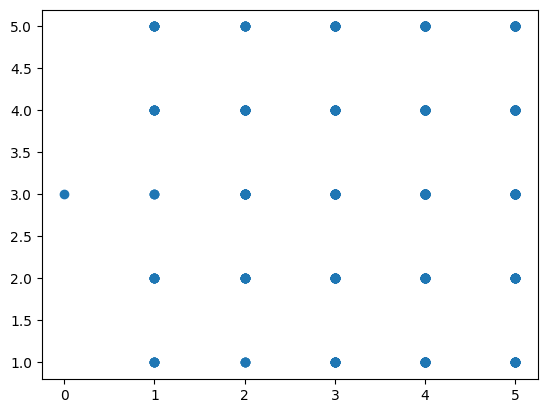

In [ ]:
plt.scatter(df2['Inflight service'], df2['Cleanliness'])
plt.show()

In [ ]:
df2[['Age']].corr()

,Age
Age,1.0


In [ ]:
##IQR
#Q3-Q1

Q3=df2['Age'].quantile(0.75)
Q1=df2['Age'].quantile(0.25)
IQR=Q3-Q1
IQR

23.5